<a href="https://colab.research.google.com/github/Vishal-3600/100-Days-of-ML/blob/main/IPL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IPL 2022 CAPSTONE PROJECT**

The Indian Premier League is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match level data to derive meaningful insights and understand match outcomes, player performance, and team dynamics.

These are some of the important columns that we'll focus on for meaningfull insights in this project.

column name: Variable Type



* date: string
*   venue:string
*   stage:string

*   team1:string

*    team2:string

*   toss_winner:string

*   toss_decision:string

*   first_ings_score:integer
*   second_ings_score:integer


*   match_winner:string


*   won_by:string


*   margin:integer


*  player_of_the_match:string

*   top_scorer:string

*   highscore:integer

*   best_bowling:string
*   best_bowling_fgure:string


*   gure:string












**Loading the libraries and Dataset**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('/content/drive/MyDrive/IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


**Basic Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

**check the size and shape of the dataset**

In [ ]:
df.shape

(74, 20)

In [ ]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


**Now let's see how many columns have null values in total**

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


**Now some Basic Questions**

1. Which team won the most matches?

In [ ]:
df1=df.groupby('match_winner')['match_winner'].count().sort_values(ascending=False)
df1

,match_winner
match_winner,
Gujarat,12
Rajasthan,10
Lucknow,9
Banglore,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


In [ ]:
match_winners=df['match_winner'].value_counts()
match_winners

,count
match_winner,
Gujarat,12
Rajasthan,10
Banglore,9
Lucknow,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


Text(0.5, 1.0, 'Most match wins by team')

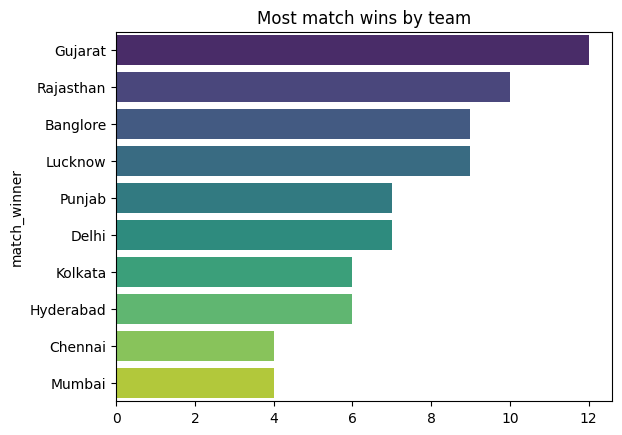

In [ ]:
sns.barplot(y=match_winners.index,x=match_winners.values,palette='viridis')
plt.title('Most match wins by team')

2.Toss Decision Trends

In [ ]:
toss=df['toss_decision'].value_counts()
toss

,count
toss_decision,
Field,59
Bat,15


Text(0.5, 1.0, 'Toss Decision')

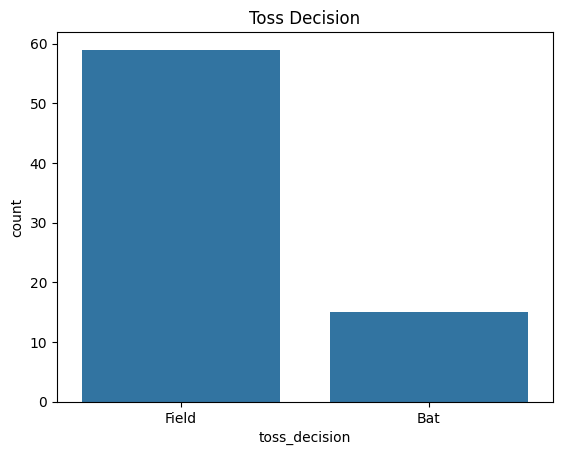

In [ ]:
sns.countplot(x=df['toss_decision'])
plt.title('Toss Decision')

In [ ]:
df1=(df['toss_winner']==df['match_winner']).value_counts()
df1

,count
False,38
True,36


In [ ]:
df1 = (df['toss_winner'] == df['match_winner']).value_counts()

toss_win_match = df1[True]
total_matches = df1.sum()

percentage = (toss_win_match / total_matches) * 100
print(percentage)

48.64864864864865


4.How do teams wins? (Runs vs Wickets)

In [ ]:
df2=df.groupby('match_winner')['won_by'].value_counts()
df2

match_winner  won_by 
Banglore      Runs       5
              Wickets    4
Chennai       Runs       3
              Wickets    1
Delhi         Wickets    4
              Runs       3
Gujarat       Wickets    8
              Runs       4
Hyderabad     Wickets    5
              Runs       1
Kolkata       Wickets    4
              Runs       2
Lucknow       Runs       7
              Wickets    2
Mumbai        Wickets    3
              Runs       1
Punjab        Runs       4
              Wickets    3
Rajasthan     Runs       7
              Wickets    3
Name: count, dtype: int64

Text(0.5, 1.0, 'won by')

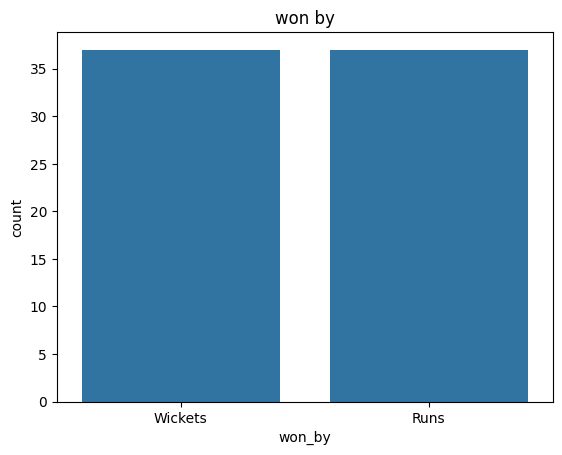

In [ ]:
sns.countplot(x=df['won_by'])
plt.title('won by')

**Key Player Performance**

1. Most "player of the match " Awards

In [ ]:
count=df['player_of_the_match'].value_counts()
count

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


In [ ]:
print(count.index[0],count[0])

Kuldeep Yadav 4


In [ ]:
count1=count.head(10)
count1

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


Text(0.5, 1.0, 'Most player of the match Awards')

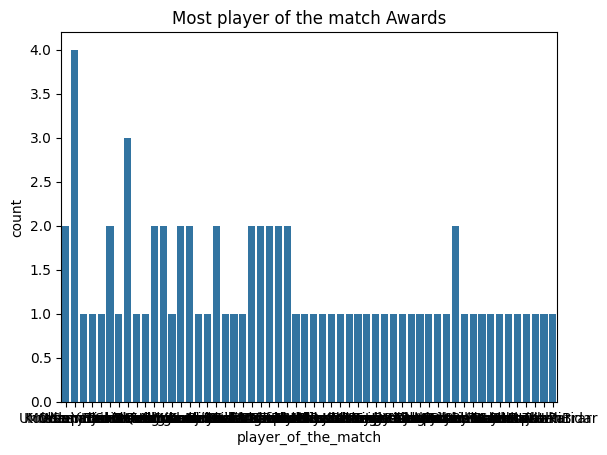

In [ ]:
sns.countplot(x=df['player_of_the_match'])
plt.title('Most player of the match Awards')

Text(0.5, 1.0, 'Most Player of the match awards')

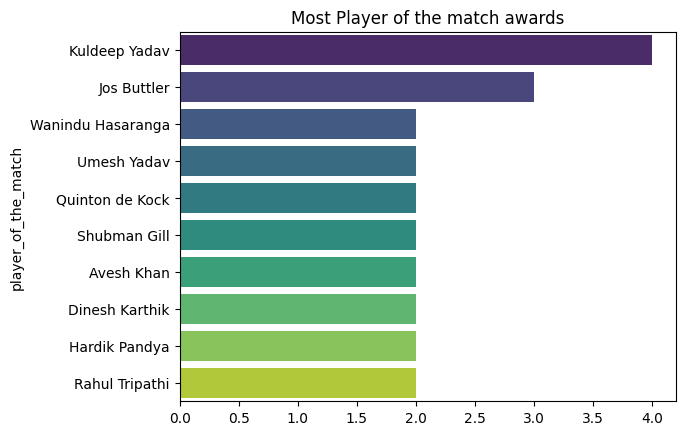

In [ ]:
sns.barplot(x=count1.values,y=count1.index,palette='viridis')
plt.title('Most Player of the match awards')

2. Top Scorer

In [ ]:
scorer=df.groupby('top_scorer')['top_scorer'].count().sort_values(ascending=False)
scorer

,top_scorer
top_scorer,
Jos Buttler,7
Quinton de Kock,5
Liam Livingstone,4
KL Rahul,4
Shubman Gill,4
David Warner,3
Faf du Plessis,3
W. Saha,3
Ishan Kishan,3


In [ ]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False)
high.head(2)

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


<Axes: ylabel='top_scorer'>

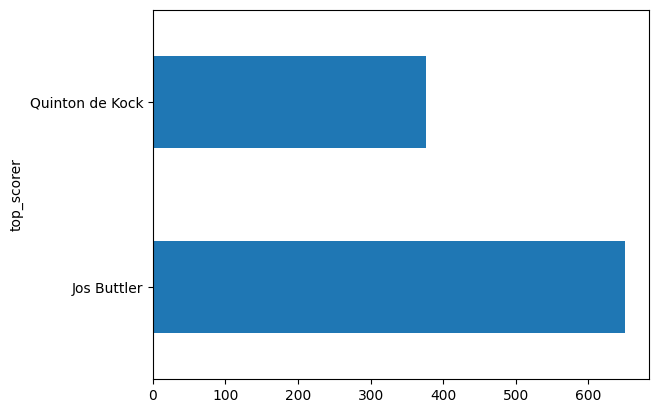

In [ ]:
high.head(2).plot(kind='barh')

10 best Bowling Figures

In [ ]:
bowling=df.groupby('best_bowling')['best_bowling_figure'].count().sort_values(ascending=False)
bowling.head(10)

,best_bowling_figure
best_bowling,
Yuzvendra Chahal,5
Rashid Khan,4
Kagiso Rabada,3
Josh Hazlewood,3
T Natarajan,3
Kuldeep Yadav,3
Avesh Khan,3
Jasprit Bumrah,3
Andre Russell,2


In [ ]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)
top_bowlers.head(10)

,highest_wickets
best_bowling,
Yuzvendra Chahal,17
Jasprit Bumrah,11
Kuldeep Yadav,11
Rashid Khan,11
Josh Hazlewood,10
Kagiso Rabada,10
Avesh Khan,10
Umran Malik,9
Wanindu Hasaranga,9


<Axes: ylabel='best_bowling'>

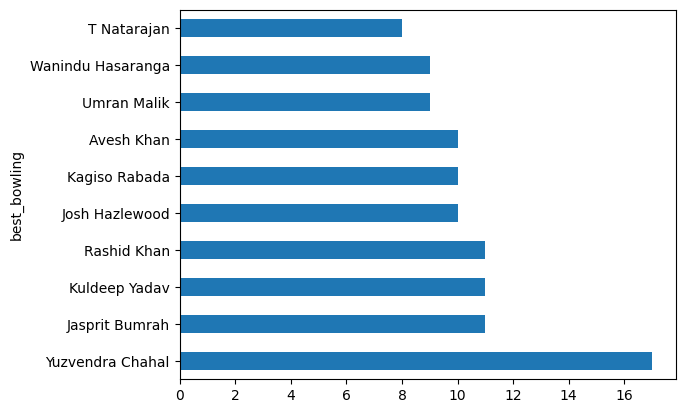

In [ ]:
top_bowlers.head(10).plot(kind='barh')

**Venue Analysis**

most matches played by Venue

In [ ]:
venue_count=df['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


Text(0.5, 1.0, 'Most matches played by Venue')

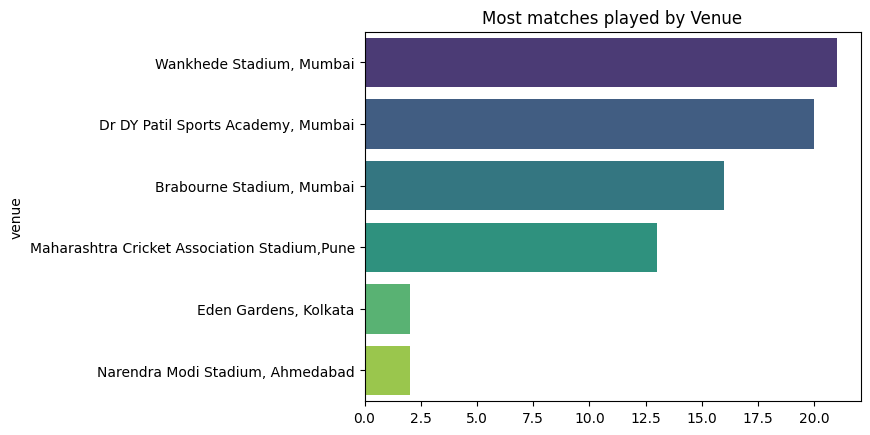

In [ ]:
sns.barplot(x=venue_count.values,y=venue_count.index,palette='viridis')
plt.title('Most matches played by Venue')

**Custom Questions & Insights**

Q1: Who won the highest margin by runs?


In [54]:
highest_margin = df.sort_values(by='margin', ascending=False)
highest_margin[['match_winner', 'margin']].head(1)

,match_winner,margin
54,Chennai,91


In [56]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [61]:
df.sort_values(by='highscore',ascending=False).head(1)[['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [63]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

In [ ]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]